Data minning de la base de datos creada para conocer los gustos de las personas

Dimensiones del dataset: (101, 14)

Primeras filas:
     Marca temporal ¿En que rango de edad te encuentras?  \
0  6/5/2026 0:22:23                              18 a 29   
1  6/5/2026 0:25:14                              30 a 49   
2  6/5/2026 0:26:43                              18 a 29   
3  6/5/2026 0:26:49                              30 a 49   
4  6/5/2026 0:40:13                              18 a 29   

  ¿Para quien compras generalmente el aguacate?  \
0                               para mi familia   
1                                  solo para mi   
2                               para mi familia   
3                               para mi familia   
4                               para mi familia   

  ¿En que estado de madurez prefieres el aguacate al comprarlo?  \
0  verde(para madurar en casa y usarlo despues de...              
1                           maduro(listo para comer)              
2                           maduro(listo para comer)              
3           

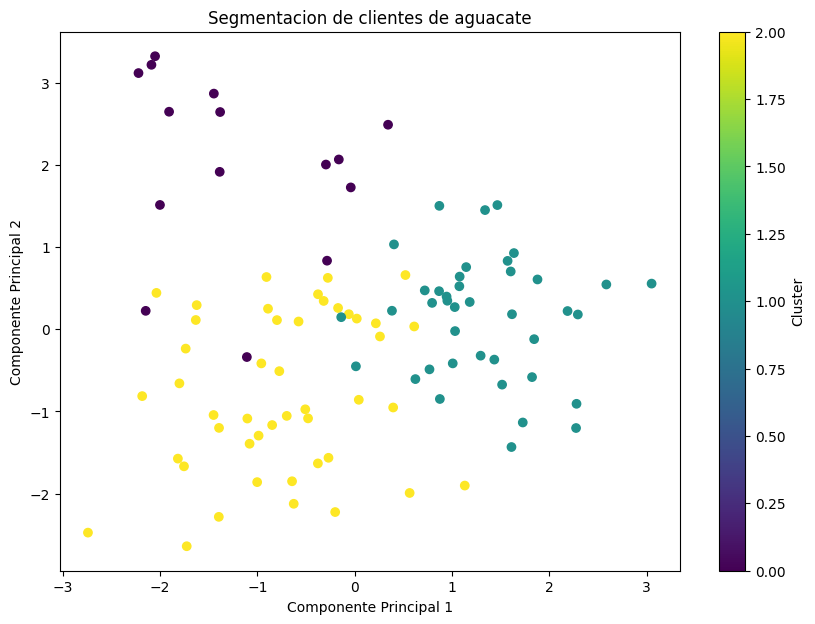


Archivo 'clientes_con_clusters.csv' guardado


In [23]:
#importa la libreria para manejar tablas de datos
import pandas as pd
#importa la libreria para operaciones matematicas
import numpy as np
#importa la libreria para hacer graficas
import matplotlib.pyplot as plt
#importa el algoritmo de clustering k-means
from sklearn.cluster import KMeans
#importa herramientas para escalar datos y codificar texto
from sklearn.preprocessing import StandardScaler, LabelEncoder
#importa herramienta para rellenar valores vacios
from sklearn.impute import SimpleImputer
#importa herramienta para reducir dimensiones
from sklearn.decomposition import PCA

#carga el archivo csv y lo guarda en una variable llamada df
df = pd.read_csv('/content/respuestas_aguacates.csv')

#muestra cuantas filas y columnas tiene el dataset
print("Dimensiones del dataset:", df.shape)
#imprime un titulo
print("\nPrimeras filas:")
#muestra las primeras 5 filas del dataset
print(df.head())
#imprime un titulo
print("\nNombres de columnas:")
#muestra la lista de nombres de las columnas
print(df.columns.tolist())

#limpia los nombres de las columnas quitando espacios al inicio o final
df.columns = df.columns.str.strip()

#selecciona todas las columnas menos la de marca temporal
cols_para_modelar = [col for col in df.columns if col != 'Marca temporal']

#crea un nuevo dataframe solo con las columnas seleccionadas
df_modelo = df[cols_para_modelar].copy()

#crea un imputador que rellena valores vacios con el valor mas comun
imputer = SimpleImputer(strategy='most_frequent')
#aplica el imputador y guarda el resultado
df_imputado = pd.DataFrame(imputer.fit_transform(df_modelo), columns=df_modelo.columns)

#crea un diccionario vacio para guardar los codificadores
label_encoders = {}
#copia el dataframe imputado para no modificar el original
df_codificado = df_imputado.copy()
#recorre cada columna del dataframe
for col in df_codificado.columns:
    #crea un codificador para esa columna
    le = LabelEncoder()
    #convierte el texto a numeros enteros
    df_codificado[col] = le.fit_transform(df_codificado[col].astype(str))
    #guarda el codificador en el diccionario
    label_encoders[col] = le

#crea un escalador para estandarizar los datos
scaler = StandardScaler()
#escala los datos para que tengan media cero y desviacion uno
datos_escalados = scaler.fit_transform(df_codificado)

#muestra cuantos clientes y cuantas caracteristicas hay
print(f"\nDatos listos: {len(datos_escalados)} clientes, {datos_escalados.shape[1]} caracteristicas")

#crea el modelo de clustering con 3 grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
#aplica el clustering a los datos escalados
clusters = kmeans.fit_predict(datos_escalados)
#agrega una columna al dataframe con el numero de cluster de cada cliente
df_imputado['cluster'] = clusters

#imprime un titulo
print("\nDistribucion de clusters:")
#muestra cuantos clientes hay en cada cluster
print(df_imputado['cluster'].value_counts())

#crea un modelo pca para reducir a 2 dimensiones
pca = PCA(n_components=2)
#aplica pca a los datos escalados
datos_pca = pca.fit_transform(datos_escalados)

#crea una figura de tamaño 10 por 7 pulgadas
plt.figure(figsize=(10, 7))
#dibuja los puntos coloreados por cluster
scatter = plt.scatter(datos_pca[:, 0], datos_pca[:, 1], c=clusters, cmap='viridis')
#etiqueta del eje x
plt.xlabel('Componente Principal 1')
#etiqueta del eje y
plt.ylabel('Componente Principal 2')
#titulo de la grafica
plt.title('Segmentacion de clientes de aguacate')
#agrega una barra de colores que indica a que cluster pertenece cada punto
plt.colorbar(scatter, label='Cluster')
#guarda la grafica como un archivo de imagen
plt.savefig('segmentacion_aguacate.png')
#muestra la grafica en pantalla
plt.show()

#guarda el dataframe con los clusters asignados como archivo csv
df_imputado.to_csv('clientes_con_clusters.csv', index=False)
#mensaje de confirmacion de que el archivo se guardo
print("\nArchivo 'clientes_con_clusters.csv' guardado")

Se identificaron 4 segmentos de clientes (azul oscuro, azul claro, amarillo, verde)

Los grupos están bien separados, lo que significa que realmente hay diferentes tipos de consumidores de aguacate

El grupo azul oscuro (Cluster 1) parece ser el más grande o el más concentrado

Los grupos amarillo y verde están más dispersos, lo que podría indicar que tienen preferencias más variadas o que hay menos clientes de esos tipos

mineria de patrones: market basket analysis

In [16]:
#Importar la librería pandas para trabajar con tablas de datos
import pandas as pd

#cargar el archivo CSV (la encuesta) y guardarlo en una variable llamada df
df = pd.read_csv('respuestas_aguacates.csv')

#limpiar los nombres de las columnas: quitar espacios al inicio o final
df.columns = df.columns.str.strip()

#eliminar filas donde la columna de edad esté vacía (valores nan)
#    Esto evita errores al analizar datos incompletos
df = df.dropna(subset=['¿En que rango de edad te encuentras?'])

#definir qué preguntas vamos a analizar (las más relevantes para el negocio)
preguntas = [
    '¿Generalmente, donde compras el aguacate?',        #lugar de compra
    '¿Consideras que el precio actual del aguacate es accesible?',  #percepción de precio
    '¿Que harías si el precio aumenta considerablemente?'  #lealtad
]

#imprimir un título para el reporte
print("PATRON POR EDAD (respuesta mas comun en cada pregunta)")
print("=" * 70)

#recorrer cada grupo de edad diferente (18-29, 30-49, mas de 50)
for edad in df['¿En que rango de edad te encuentras?'].unique():

    #mostrar qué edad estamos analizando en este momento
    print(f"\nEdad: {edad}")

    #filtrar los datos: quedarnos solo con los clientes de esta edad
    df_edad = df[df['¿En que rango de edad te encuentras?'] == edad]

    #imprimir subtítulo
    print("  Perfil tipico de este segmento:")

    #obtener la respuesta MÁS COMÚN (moda) para el lugar de compra
    #     .mode() calcula la moda, [0] toma la primera si hay varias
    lugar = df_edad[preguntas[0]].mode()[0]

    #obtener la respuesta más común para "precio accesible"
    precio = df_edad[preguntas[1]].mode()[0]

    #obtener la respuesta más común para "qué haría si sube el precio"
    reaccion = df_edad[preguntas[2]].mode()[0]

    #mostrar las tres respuestas más comunes de este grupo de edad
    print(f"    - Compra en: {lugar}")
    print(f"    - Considera el precio accesible? {precio}")
    print(f"    - Si sube el precio: {reaccion}")

    #explicar qué significa este patrón
    print("\n  Que significa este patron:")

    #interpretar la percepción del precio
    if precio == 'no':
        print(f"    Los clientes de {edad} sienten que el precio no es accesible.")
    else:
        print(f"    Los clientes de {edad} aceptan el precio actual.")

    #interpretar la reacción ante un aumento de precio
    if reaccion == 'dejar de comprarlo hasta que baje el precio':
        print(f"    Si el precio sube, este segmento dejaria de comprar temporalmente.")
    elif reaccion == 'comprar menos cantidad':
        print(f"    Si el precio sube, este segmento reduciria su consumo pero no dejaria de comprar.")
    elif reaccion == 'buscarlo en otro puesto o tienda mas barato':
        print(f"    Si el precio sube, este segmento buscaria opciones mas baratas en otro lugar.")
    else:
        print(f"    Si el precio sube, la reaccion mas comun es: {reaccion}")

    #interpretar el lugar de compra (para saber dónde llegar a cada segmento)
    if lugar == 'tianguis':
        print(f"    Su canal principal es el tianguis. Ahi concentran sus compras.")
    elif lugar == 'recauderias y locales establecidos':
        print(f"    Su canal principal son las recauderias o locales establecidos.")
    elif lugar == 'puestitos de la calle':
        print(f"    Su canal principal son los puestitos de la calle.")
    elif lugar == 'supermercados':
        print(f"    Su canal principal son los supermercados.")

    #linea separadora para distinguir entre un grupo de edad y el siguiente
    print("-" * 70)

PATRON POR EDAD (respuesta mas comun en cada pregunta)

Edad: 18 a 29
  Perfil tipico de este segmento:
    - Compra en: tianguis
    - Considera el precio accesible? no
    - Si sube el precio: comprar menos cantidad

  Que significa este patron:
    Los clientes de 18 a 29 sienten que el precio no es accesible.
    Si el precio sube, este segmento reduciria su consumo pero no dejaria de comprar.
    Su canal principal es el tianguis. Ahi concentran sus compras.
----------------------------------------------------------------------

Edad: 30 a 49
  Perfil tipico de este segmento:
    - Compra en: recauderias y locales establecidos
    - Considera el precio accesible? si
    - Si sube el precio: comprar menos cantidad

  Que significa este patron:
    Los clientes de 30 a 49 aceptan el precio actual.
    Si el precio sube, este segmento reduciria su consumo pero no dejaria de comprar.
    Su canal principal son las recauderias o locales establecidos.
-----------------------------------

Mineria de marketing

REPORTE DE MARKETING - CLIENTES DE AGUACATE

1. PERFIL DEL CLIENTE TIPICO
----------------------------------------
  Edad: 18 a 29
  Lugar de compra: tianguis
  Madurez preferida: una mezcla de ambos
  Caracteristica principal: que tenga un tamaño adecuado
  Frecuencia: cada 15 dias
  Precio accesible? no

2. SEGMENTOS POR EDAD
----------------------------------------

  18 a 29:
    Compra en: tianguis
    Precio accesible? no
    Si sube precio: comprar menos cantidad

  30 a 49:
    Compra en: recauderias y locales establecidos
    Precio accesible? si
    Si sube precio: comprar menos cantidad

  mas de 50:
    Compra en: recauderias y locales establecidos
    Precio accesible? no
    Si sube precio: comprar menos cantidad

3. CANALES DE COMPRA POR EDAD
----------------------------------------
¿Generalmente, donde compras el aguacate?  puestitos de la calle  \
¿En que rango de edad te encuentras?                               
18 a 29                                                

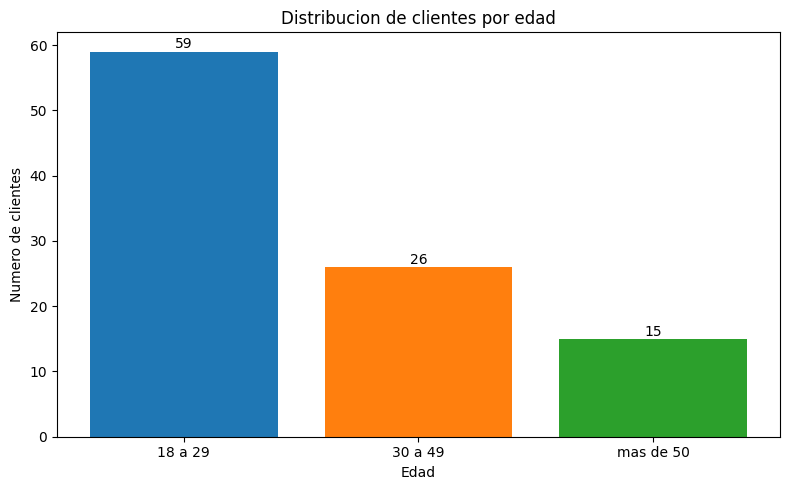

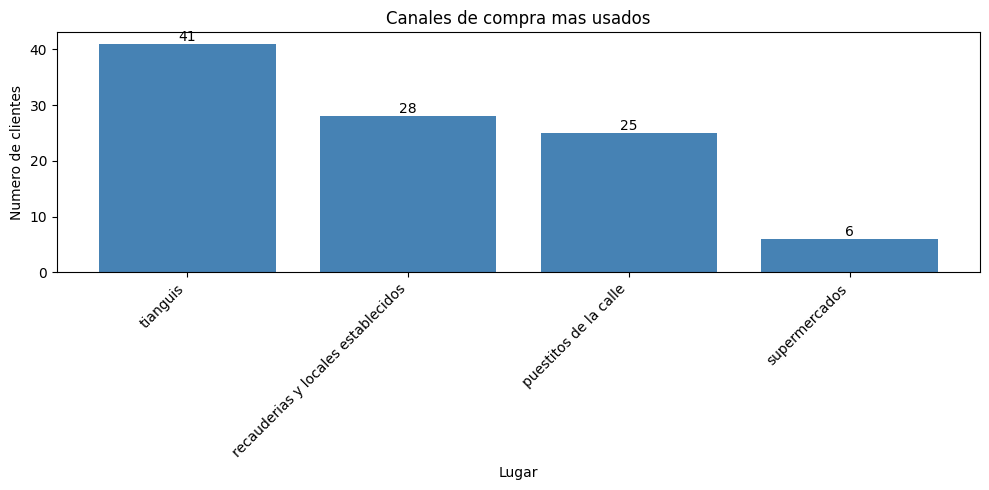

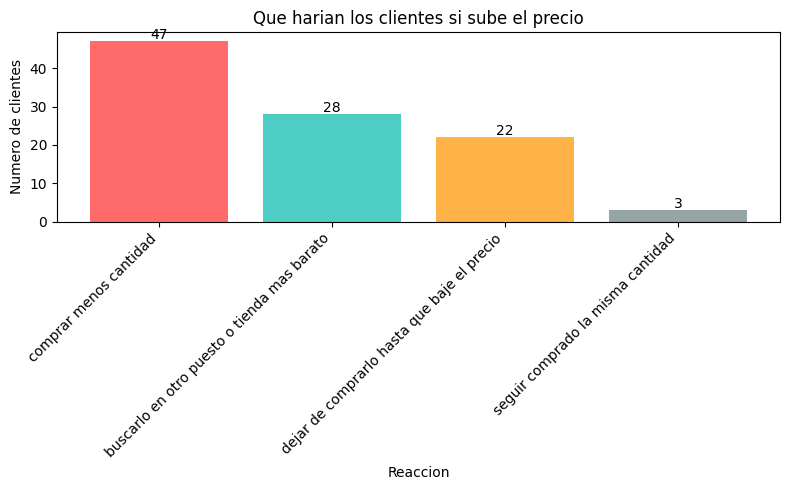


RESUMEN EJECUTIVO - CONCLUSIONES DE MARKETING

Cliente tipico: 18 a 29, compra en tianguis, busca que tenga un tamaño adecuado

Canal principal: tianguis con 41 clientes

Problema principal: 54 de 100 clientes sienten el precio caro

Riesgo: 22 clientes dejarian de comprar si el precio sube

Oportunidad: Los jovenes son 59 de 100 clientes (59%)

RECOMENDACIONES:
  1. Enfocar promociones en tianguis (principal canal)
  2. Dirigir ofertas a jovenes de 18 a 29 años (mayor segmento)
  3. Destacar frescura y sabor en la comunicacion
  4. Ofrecer promociones por volumen para retener a los sensibles al precio


In [22]:
#importar librerías necesarias
import pandas as pd  #para manejar tablas de datos
import matplotlib.pyplot as plt  #para hacer gráficas
import seaborn as sns  #para gráficas más bonitas (aunque no se usa mucho aquí)
from collections import Counter  #para contar frecuencias (aunque no se usa directamente)

#cargar el archivo CSV con los datos de la encuesta
df = pd.read_csv('respuestas_aguacates.csv')

#limpiar los nombres de las columnas (quitar espacios al inicio o final)
df.columns = df.columns.str.strip()

#eliminar filas donde la edad esté vacía (valores nan) para evitar errores
df = df.dropna(subset=['¿En que rango de edad te encuentras?'])

#imprimir título principal del reporte
print("=" * 70)
print("REPORTE DE MARKETING - CLIENTES DE AGUACATE")
print("=" * 70)

#cliente tipico(usando moda)
# ==================================================
print("\n1. PERFIL DEL CLIENTE TIPICO")
print("-" * 40)

#calcular la edad más común (moda)
edad_comun = df['¿En que rango de edad te encuentras?'].mode()[0]

#calcular el lugar de compra más común
lugar_comun = df['¿Generalmente, donde compras el aguacate?'].mode()[0]

#calcular la madurez preferida más común
madurez_comun = df['¿En que estado de madurez prefieres el aguacate al comprarlo?'].mode()[0]

#calcular la característica más valorada
caracteristica_comun = df['¿Que características son mas importantes para ti al elegir el aguacate?'].mode()[0]

#calcular la frecuencia de compra más común
frecuencia_comun = df['¿Con que frecuencia compras aguacate?'].mode()[0]

#calcular la percepción de precio más común
precio_comun = df['¿Consideras que el precio actual del aguacate es accesible?'].mode()[0]

#mostrar el perfil del cliente típico
print(f"  Edad: {edad_comun}")
print(f"  Lugar de compra: {lugar_comun}")
print(f"  Madurez preferida: {madurez_comun}")
print(f"  Caracteristica principal: {caracteristica_comun}")
print(f"  Frecuencia: {frecuencia_comun}")
print(f"  Precio accesible? {precio_comun}")

# ==================================================
#segmentos por edad
# ==================================================
print("\n2. SEGMENTOS POR EDAD")
print("-" * 40)

#recorrer cada grupo de edad único (18-29, 30-49, mas de 50)
for edad in df['¿En que rango de edad te encuentras?'].unique():

    #filtrar solo los clientes de esta edad
    df_edad = df[df['¿En que rango de edad te encuentras?'] == edad]

    #obtener el lugar de compra más común en este grupo de edad
    lugar = df_edad['¿Generalmente, donde compras el aguacate?'].mode()[0]

    #obtener la percepción de precio más común en este grupo
    precio = df_edad['¿Consideras que el precio actual del aguacate es accesible?'].mode()[0]

    #obtener la reacción más común ante aumento de precio
    reaccion = df_edad['¿Que harías si el precio aumenta considerablemente?'].mode()[0]

    #mostrar los resultados para este grupo de edad
    print(f"\n  {edad}:")
    print(f"    Compra en: {lugar}")
    print(f"    Precio accesible? {precio}")
    print(f"    Si sube precio: {reaccion}")

# ==================================================
#compra por edad
# ==================================================
print("\n3. CANALES DE COMPRA POR EDAD")
print("-" * 40)

#crear una tabla que cruza edad vs lugar de compra
#las filas son edades, las columnas son lugares, los valores son conteos
tabla_canales = pd.crosstab(df['¿En que rango de edad te encuentras?'],
                            df['¿Generalmente, donde compras el aguacate?'])
print(tabla_canales)

# ==================================================
#que valora cada edad
# ==================================================
print("\n4. CARACTERISTICAS VALORADAS POR EDAD")
print("-" * 40)

#recorrer cada grupo de edad
for edad in df['¿En que rango de edad te encuentras?'].unique():
    df_edad = df[df['¿En que rango de edad te encuentras?'] == edad]
    #obtener la característica más valorada por este grupo
    caracteristica = df_edad['¿Que características son mas importantes para ti al elegir el aguacate?'].mode()[0]
    print(f"  {edad}: valora {caracteristica}")

# ==================================================
#(riesgo de abandono)
# ==================================================
print("\n5. RIESGO DE ABANDONO POR EDAD")
print("-" * 40)

#recorrer cada grupo de edad
for edad in df['¿En que rango de edad te encuentras?'].unique():
    df_edad = df[df['¿En que rango de edad te encuentras?'] == edad]
    total = len(df_edad)  # Total de clientes en este grupo

    #contar cuántos dejarían de comprar si sube el precio
    abandonan = len(df_edad[df_edad['¿Que harías si el precio aumenta considerablemente?'] == 'dejar de comprarlo hasta que baje el precio'])

    #contar cuántos comprarían menos cantidad
    reducen = len(df_edad[df_edad['¿Que harías si el precio aumenta considerablemente?'] == 'comprar menos cantidad'])

    #mostrar resultados
    print(f"\n  {edad}:")
    print(f"    Abandonan si sube precio: {abandonan}/{total} ({abandonan/total*100:.0f}%)")
    print(f"    Reducen consumo: {reducen}/{total} ({reducen/total*100:.0f}%)")

# ==================================================
#graficar
# ==================================================
print("\n6. GENERANDO GRAFICAS...")
print("-" * 40)

#GRÁFICA 1:distribución por edad
plt.figure(figsize=(8, 5))  # Tamaño de la figura
conteo_edad = df['¿En que rango de edad te encuentras?'].value_counts()  # contar cuántos por edad
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']  #colores para las barras
barras = plt.bar(conteo_edad.index, conteo_edad.values, color=colores)  # dibujar barras
plt.title('Distribucion de clientes por edad')  #titulo
plt.xlabel('Edad')  #etiqueta eje X
plt.ylabel('Numero de clientes')  #etiqueta eje Y

#agregar números encima de cada barra
for barra in barras:
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
             str(int(barra.get_height())), ha='center')

plt.tight_layout()  #ajustar márgenes
plt.savefig('distribucion_edad.png', dpi=150)  #guardar la imagen
plt.show()  #mostrar la gráfica

#GRÁFICA 2: canales de compra
plt.figure(figsize=(10, 5))
canales = df['¿Generalmente, donde compras el aguacate?'].value_counts()
plt.bar(canales.index, canales.values, color='steelblue')
plt.title('Canales de compra mas usados')
plt.xlabel('Lugar')
plt.ylabel('Numero de clientes')
plt.xticks(rotation=45, ha='right')  #rotar etiquetas para que no se encimen

#agregar números encima de cada barra
for i, v in enumerate(canales.values):
    plt.text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.savefig('canales_compra.png', dpi=150)
plt.show()

#GRÁFICA 3: reacción ante aumento de precio
plt.figure(figsize=(8, 5))
reacciones = df['¿Que harías si el precio aumenta considerablemente?'].value_counts()
colores_reac = ['#ff6b6b', '#4ecdc4', '#ffb347', '#95a5a6']
plt.bar(reacciones.index, reacciones.values, color=colores_reac[:len(reacciones)])
plt.title('Que harian los clientes si sube el precio')
plt.xlabel('Reaccion')
plt.ylabel('Numero de clientes')
plt.xticks(rotation=45, ha='right')

#agregar números encima de cada barra
for i, v in enumerate(reacciones.values):
    plt.text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.savefig('reaccion_precio.png', dpi=150)
plt.show()

# ==================================================
#resumen
# ==================================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO - CONCLUSIONES DE MARKETING")
print("=" * 70)

#calcular totales para el resumen
total_clientes = len(df)
jovenes = len(df[df['¿En que rango de edad te encuentras?'] == '18 a 29'])
abandonan_total = len(df[df['¿Que harías si el precio aumenta considerablemente?'] == 'dejar de comprarlo hasta que baje el precio'])
precio_caro = len(df[df['¿Consideras que el precio actual del aguacate es accesible?'] == 'no'])

#mostrar conclusiones
print(f"\nCliente tipico: {edad_comun}, compra en {lugar_comun}, busca {caracteristica_comun}")
print(f"\nCanal principal: {lugar_comun} con {canales[lugar_comun]} clientes")
print(f"\nProblema principal: {precio_caro} de {total_clientes} clientes sienten el precio caro")
print(f"\nRiesgo: {abandonan_total} clientes dejarian de comprar si el precio sube")
print(f"\nOportunidad: Los jovenes son {jovenes} de {total_clientes} clientes ({jovenes/total_clientes*100:.0f}%)")

#recomendaciones finales
print("\nRECOMENDACIONES:")
print("  1. Enfocar promociones en tianguis (principal canal)")
print("  2. Dirigir ofertas a jovenes de 18 a 29 años (mayor segmento)")
print("  3. Destacar frescura y sabor en la comunicacion")
print("  4. Ofrecer promociones por volumen para retener a los sensibles al precio")